# Eksperimen Machine Learning - Heart Disease Prediction

**Nama**: Dinda Putri Rahmatia  
**Username Dicoding**: dinda_putri_rahmatia  
**Dataset**: Heart Disease (Cleveland UCI) - 303 sampel, 13 fitur klinis, klasifikasi biner  

## Deskripsi Dataset

Dataset Heart Disease Cleveland merupakan salah satu dataset medis yang paling banyak digunakan dalam penelitian machine learning di bidang kardiovaskular. Dataset ini berisi data klinis dari 303 pasien yang mencakup berbagai parameter seperti usia, tekanan darah, kadar kolesterol, hingga hasil elektrokardiogram. Target klasifikasi adalah ada atau tidaknya penyakit jantung (0 = tidak ada, 1 = ada).

**Fitur Dataset:**
- `age`: Usia pasien (tahun)
- `sex`: Jenis kelamin (1=laki-laki, 0=perempuan)
- `cp`: Tipe nyeri dada (1-4)
- `trestbps`: Tekanan darah istirahat (mmHg)
- `chol`: Kolesterol serum (mg/dl)
- `fbs`: Gula darah puasa > 120 mg/dl (1=ya, 0=tidak)
- `restecg`: Hasil elektrokardiogram istirahat (0-2)
- `thalach`: Denyut jantung maksimum
- `exang`: Angina akibat olahraga (1=ya, 0=tidak)
- `oldpeak`: Depresi ST akibat olahraga
- `slope`: Kemiringan segmen ST puncak
- `ca`: Jumlah pembuluh darah utama (0-3)
- `thal`: Thalassemia (3=normal, 6=fixed defect, 7=reversible defect)
- `target`: Ada/tidaknya penyakit jantung (0=tidak, 1=ya)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('Library berhasil diimpor!')

Library berhasil diimpor!


## 1. Load Dataset

In [2]:
df = pd.read_csv('../heart_disease_raw/heart_disease.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,45,0,2,142,126,0,1,110,1,1.2,2,2,3,1
1,63,1,4,107,259,0,1,170,0,1.2,1,1,3,0
2,57,0,1,150,279,0,0,127,0,0.2,1,2,7,1
3,41,1,2,120,233,0,0,152,0,0.6,1,2,3,1
4,49,1,2,115,297,0,0,109,0,1.4,2,2,3,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.125413,0.683168,2.597360,130.105611,247.953795,0.141914,0.514851,152.234323,0.323432,1.053135,1.590759,0.673267,4.818482,0.429043
std,9.164290,0.466011,1.117112,16.348504,47.559630,0.349539,0.580258,21.625528,0.468560,0.966414,0.617767,0.939659,1.931798,0.495758
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,79.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,2.000000,119.000000,214.000000,0.000000,0.000000,136.500000,0.000000,0.400000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,2.000000,131.000000,250.000000,0.000000,0.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,141.000000,278.000000,0.000000,1.000000,167.500000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,180.000000,379.000000,1.000000,2.000000,202.000000,1.000000,5.200000,3.000000,3.000000,7.000000,1.000000


## 2. Exploratory Data Analysis (EDA)

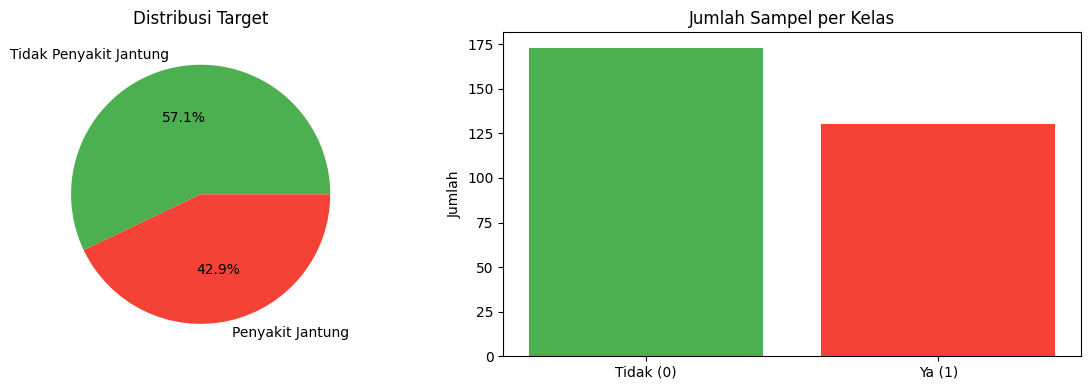

Distribusi target:
target
0    173
1    130
Name: count, dtype: int64


In [5]:
# Distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['target'].value_counts()
axes[0].pie(target_counts, labels=['Tidak Penyakit Jantung', 'Penyakit Jantung'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
axes[0].set_title('Distribusi Target')

axes[1].bar(['Tidak (0)', 'Ya (1)'], target_counts, color=['#4CAF50', '#F44336'])
axes[1].set_title('Jumlah Sampel per Kelas')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

print(f'Distribusi target:\n{target_counts}')

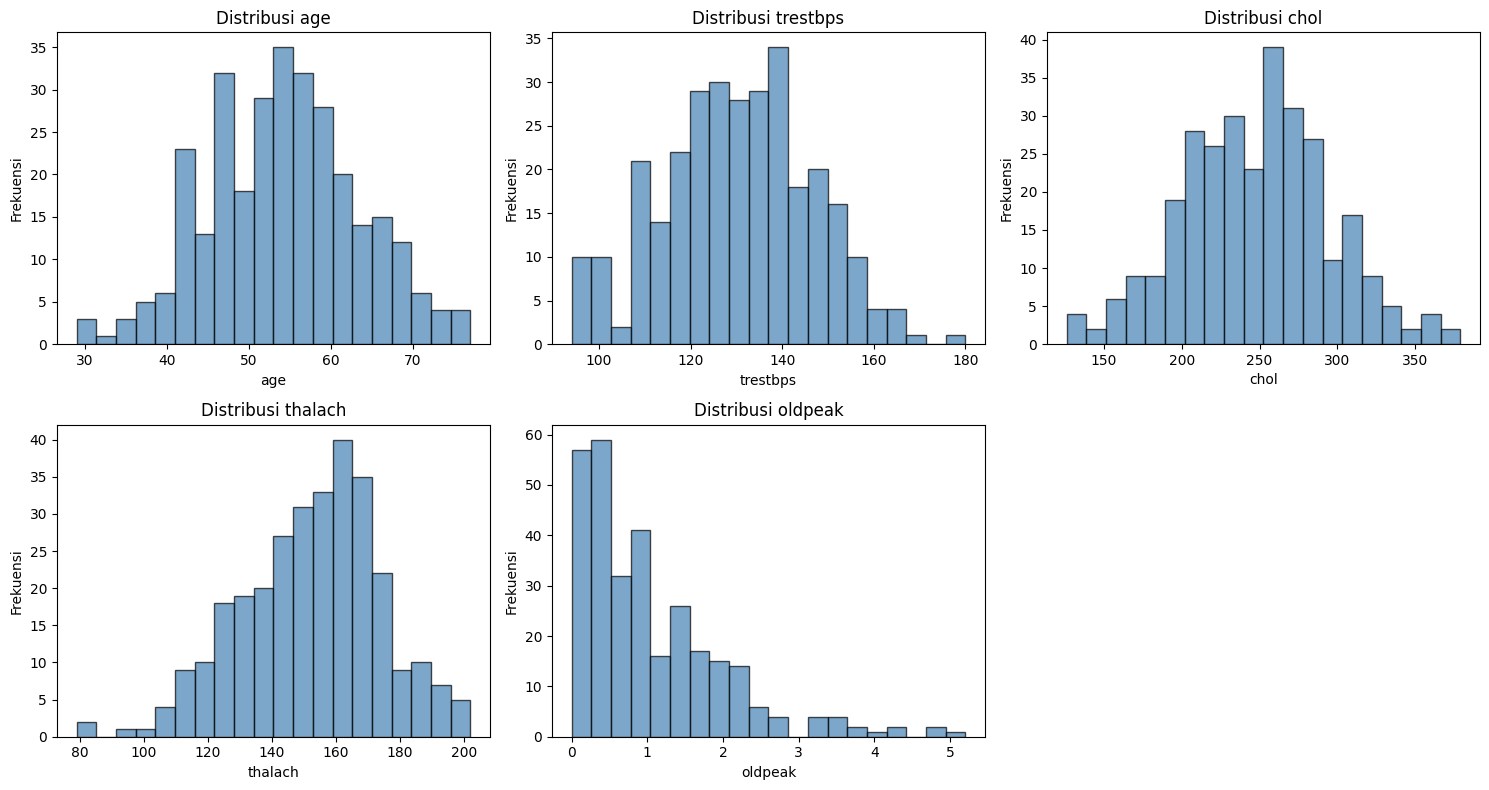

In [6]:
# Distribusi fitur numerik
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

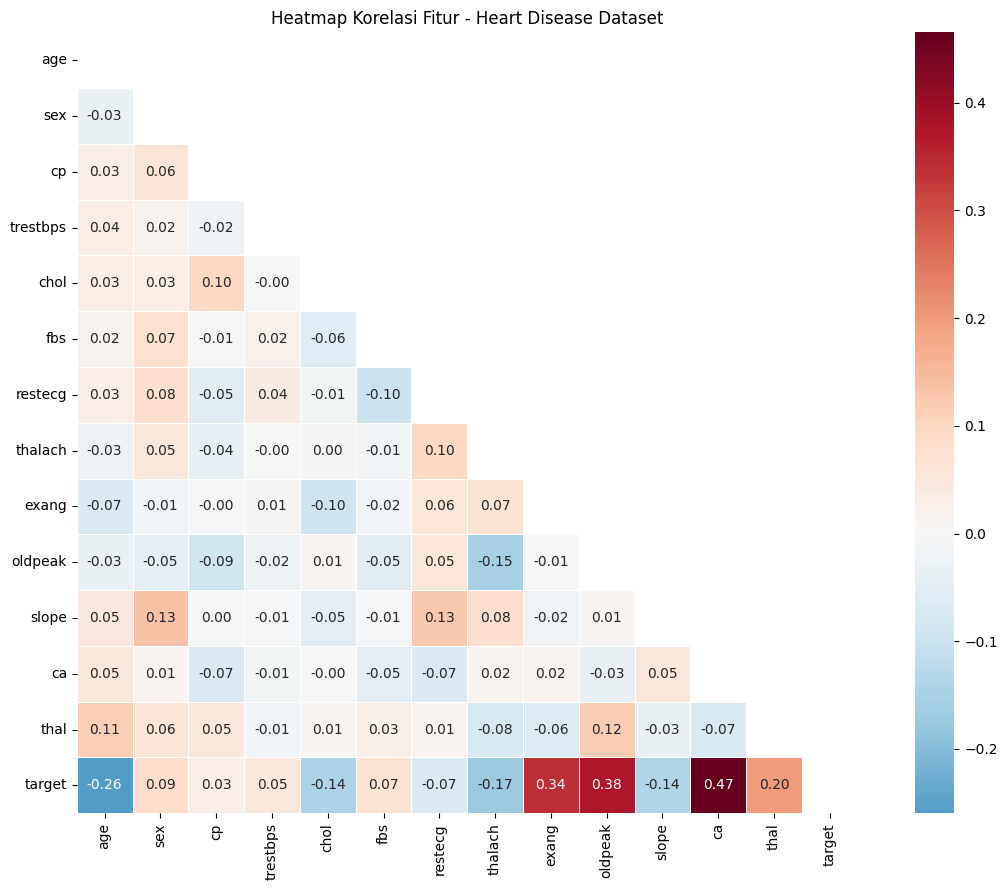

In [7]:
# Heatmap korelasi
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur - Heart Disease Dataset')
plt.tight_layout()
plt.show()

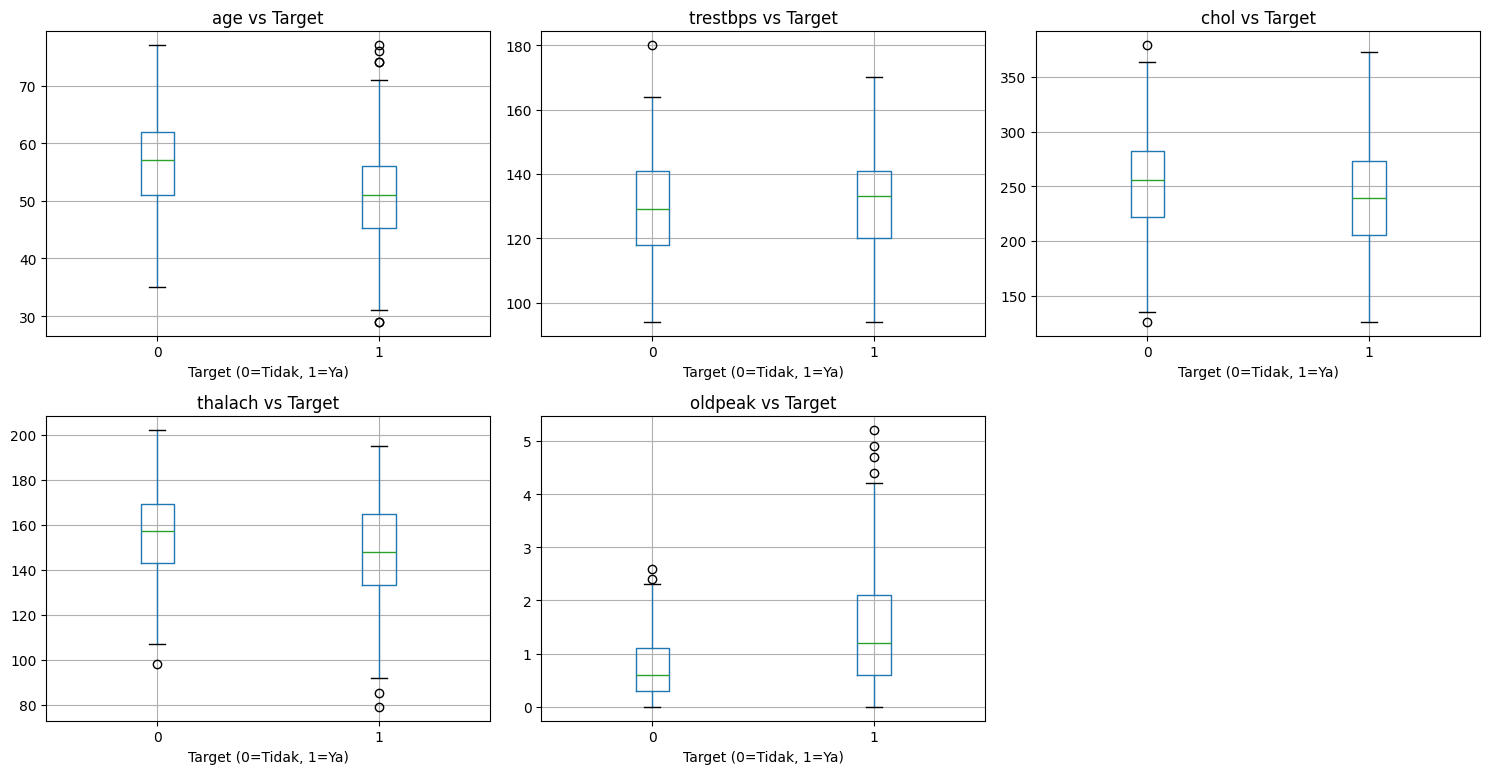

In [8]:
# Boxplot fitur vs target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_xlabel('Target (0=Tidak, 1=Ya)')

axes[5].set_visible(False)
plt.suptitle('')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [9]:
# Cek missing values
print('Missing values per kolom:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [10]:
# Handle missing values dengan SimpleImputer (median untuk numerik)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_feat = [c for c in num_cols if c != 'target']

imputer = SimpleImputer(strategy='median')
df[num_feat] = imputer.fit_transform(df[num_feat])

print(f'Missing values setelah imputation: {df.isnull().sum().sum()}')

Missing values setelah imputation: 0


In [11]:
# Cek dan hapus duplikat
print(f'Jumlah duplikat: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape setelah hapus duplikat: {df.shape}')

Jumlah duplikat: 0
Shape setelah hapus duplikat: (303, 14)


## 4. Feature Engineering

In [12]:
# Tambahkan fitur turunan yang bermakna secara klinis
df['thalach_age_ratio'] = df['thalach'] / df['age']
df['is_hypertensive'] = (df['trestbps'] >= 140).astype(int)
df['is_high_chol'] = (df['chol'] >= 240).astype(int)

print(f'Shape setelah feature engineering: {df.shape}')
print(f'Fitur baru: thalach_age_ratio, is_hypertensive, is_high_chol')
df.head()

Shape setelah feature engineering: (303, 17)
Fitur baru: thalach_age_ratio, is_hypertensive, is_high_chol


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,thalach_age_ratio,is_hypertensive,is_high_chol
0,45.0,0.0,2.0,142.0,126.0,0.0,1.0,110.0,1.0,1.2,2.0,2.0,3.0,1,2.444444,1,0
1,63.0,1.0,4.0,107.0,259.0,0.0,1.0,170.0,0.0,1.2,1.0,1.0,3.0,0,2.698413,0,1
2,57.0,0.0,1.0,150.0,279.0,0.0,0.0,127.0,0.0,0.2,1.0,2.0,7.0,1,2.228070,1,1
3,41.0,1.0,2.0,120.0,233.0,0.0,0.0,152.0,0.0,0.6,1.0,2.0,3.0,1,3.707317,0,0
4,49.0,1.0,2.0,115.0,297.0,0.0,0.0,109.0,0.0,1.4,2.0,2.0,3.0,1,2.224490,0,1


## 5. Train-Test Split & Scaling

In [13]:
import pickle
import os

TARGET_COL = 'target'
OUTPUT_DIR = 'heart_disease_preprocessing'

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f'X_train shape: {X_train_scaled.shape}')
print(f'X_test shape : {X_test_scaled.shape}')
print(f'\nDistribusi y_train:\n{y_train.value_counts()}')
print(f'\nDistribusi y_test:\n{y_test.value_counts()}')

X_train shape: (242, 16)
X_test shape : (61, 16)

Distribusi y_train:
target
0    138
1    104
Name: count, dtype: int64

Distribusi y_test:
target
0    35
1    26
Name: count, dtype: int64


In [14]:
# Simpan hasil preprocessing
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train_scaled.to_csv(f'{OUTPUT_DIR}/X_train.csv', index=False)
X_test_scaled.to_csv(f'{OUTPUT_DIR}/X_test.csv', index=False)
y_train.reset_index(drop=True).to_csv(f'{OUTPUT_DIR}/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv(f'{OUTPUT_DIR}/y_test.csv', index=False)

scaler_path = f'{OUTPUT_DIR}/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump({'scaler': scaler, 'feature_names': list(X_train.columns)}, f)

print(f'Semua file berhasil disimpan di {OUTPUT_DIR}/')
print(f'Files: {os.listdir(OUTPUT_DIR)}')

Semua file berhasil disimpan di heart_disease_preprocessing/
Files: ['scaler.pkl', 'X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']


## 6. Verifikasi Data Hasil Preprocessing

In [15]:
# Verifikasi data hasil preprocessing
X_train_check = pd.read_csv(f'{OUTPUT_DIR}/X_train.csv')
X_test_check = pd.read_csv(f'{OUTPUT_DIR}/X_test.csv')
y_train_check = pd.read_csv(f'{OUTPUT_DIR}/y_train.csv')
y_test_check = pd.read_csv(f'{OUTPUT_DIR}/y_test.csv')

print('=== Verifikasi Data ===')
print(f'X_train: {X_train_check.shape}')
print(f'X_test : {X_test_check.shape}')
print(f'y_train: {y_train_check.shape}')
print(f'y_test : {y_test_check.shape}')
print(f'\nMissing values X_train: {X_train_check.isnull().sum().sum()}')
print(f'Missing values X_test : {X_test_check.isnull().sum().sum()}')

X_train_check.head()

=== Verifikasi Data ===
X_train: (242, 16)
X_test : (61, 16)
y_train: (242, 1)
y_test : (61, 1)

Missing values X_train: 0
Missing values X_test : 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,thalach_age_ratio,is_hypertensive,is_high_chol
0,-0.961306,0.68313,0.424299,-0.369524,-0.288796,-0.39036,0.797324,0.315764,1.450022,-0.584132,-0.978918,-0.760324,-0.973738,0.843669,-0.605996,-1.104619
1,0.964844,-1.46385,-1.377112,-1.939483,-0.864011,-0.39036,-0.940986,-1.237959,-0.689645,0.902750,0.643672,2.486707,1.102426,-1.265417,-0.605996,-1.104619
2,0.322794,-1.46385,-0.476406,-1.123104,-1.521400,-0.39036,0.797324,0.362847,1.450022,-0.584132,-0.978918,1.404363,-0.973738,-0.157660,-0.605996,-1.104619
3,-0.105240,0.68313,1.325005,-0.495121,0.368593,-0.39036,0.797324,-0.155061,-0.689645,-0.265515,-0.978918,0.322020,1.102426,-0.149952,-0.605996,0.905289
4,-1.496348,0.68313,-1.377112,0.321258,-0.268253,-0.39036,0.797324,0.362847,-0.689645,-0.265515,0.643672,-0.760324,-0.973738,1.486723,-0.605996,-1.104619


In [16]:
print('Preprocessing pipeline berhasil diselesaikan!')
print(f'Dataset: Heart Disease Cleveland UCI')
print(f'Total sampel: {df.shape[0]}')
print(f'Total fitur (setelah FE): {X.shape[1]}')
print(f'Train size: {X_train_scaled.shape[0]} ({X_train_scaled.shape[0]/df.shape[0]*100:.0f}%)')
print(f'Test  size: {X_test_scaled.shape[0]} ({X_test_scaled.shape[0]/df.shape[0]*100:.0f}%)')

Preprocessing pipeline berhasil diselesaikan!
Dataset: Heart Disease Cleveland UCI
Total sampel: 303
Total fitur (setelah FE): 16
Train size: 242 (80%)
Test  size: 61 (20%)
